# 🏠 USA Housing Price Prediction — Regression Project

**Workflow:** Data Collection → Preprocessing → Train-Test Split → Feature/Target Separation → Model Building → Model Evaluation → Model Comparison → Visualization → Conclusion

**Dataset:** USA_Housing.csv | **Target Variable:** Price | **Models:** 9 Regression Algorithms

---
## 📦 Import Libraries

In [1]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
matplotlib_style = {'figure.figsize': (10, 5), 'axes.titlesize': 14, 'axes.labelsize': 12}
plt.rcParams.update(matplotlib_style)

# Preprocessing & Model Selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Regression Models
from sklearn.linear_model    import LinearRegression
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import RandomForestRegressor, BaggingRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.svm             import SVR
from sklearn.neighbors       import KNeighborsRegressor

# Metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


---
## Step 1 — Data Collection

In [2]:
# Read the dataset
df = pd.read_csv('USA_Housing.csv')

print(f'Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Dataset loaded: 5000 rows × 7 columns


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


---
## Step 2 — Data Preprocessing

In [3]:
# --- 2a. Drop 'Address' column (unique text, not useful for regression) ---
df = df.drop(columns=['Address'])
print('Columns after dropping Address:', df.columns.tolist())

Columns after dropping Address: ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Price']


In [4]:
# --- 2b. Dataset information ---
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
dtypes: float64(6)
memory usage: 234.5 KB


In [5]:
# --- 2c. Statistical summary ---
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
Avg. Area Income,5000.000000,68583.108984,10657.991214,17796.631190,61480.562388,68804.286404,75783.338666,107701.748378
Avg. Area House Age,5000.000000,5.977222,0.991456,2.644304,5.322283,5.970429,6.650808,9.519088
Avg. Area Number of Rooms,5000.000000,6.987792,1.005833,3.236194,6.299250,7.002902,7.665871,10.759588
Avg. Area Number of Bedrooms,5000.000000,3.981330,1.234137,2.000000,3.140000,4.050000,4.490000,6.500000
Area Population,5000.000000,36163.516039,9925.650114,172.610686,29403.928702,36199.406689,42861.290769,69621.713378
Price,5000.000000,1232072.654142,353117.626581,15938.657923,997577.135049,1232669.377966,1471210.204212,2469065.594175


In [6]:
# --- 2d. Check null values ---
null_counts = df.isnull().sum()
print('Null values per column:')
print(null_counts)
print(f'\nTotal nulls: {null_counts.sum()}  →  Dataset is clean ✅' if null_counts.sum() == 0 else f'\n⚠️ Found {null_counts.sum()} null values — handle before training.')

Null values per column:
Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
dtype: int64

Total nulls: 0  →  Dataset is clean ✅


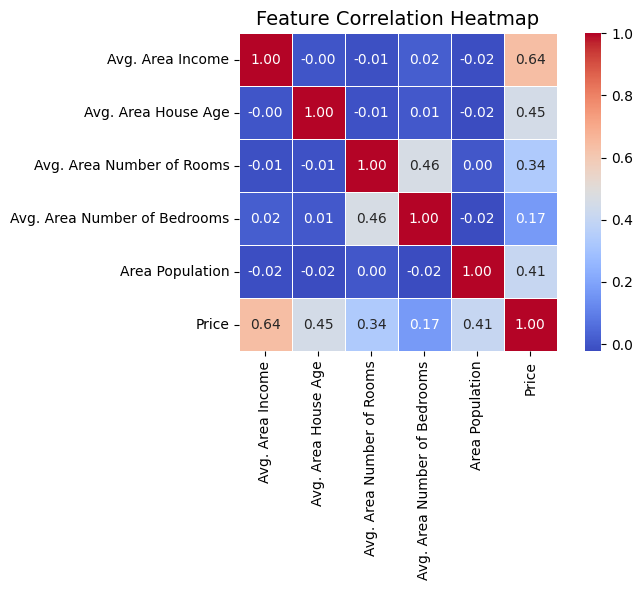

In [9]:
# --- 2e. Correlation heatmap (quick look at feature relationships) ---
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

---
## Step 3 — Train-Test Split (80 / 20)

In [10]:
# Split before feature/target separation to avoid data leakage
train_df, test_df = train_test_split(df, test_size=0.20, random_state=42)

print(f'Training set : {train_df.shape[0]} rows ({train_df.shape[0]/len(df)*100:.0f}%)')
print(f'Testing  set : {test_df.shape[0]}  rows ({test_df.shape[0]/len(df)*100:.0f}%)')

Training set : 4000 rows (80%)
Testing  set : 1000  rows (20%)


---
## Step 4 — Feature & Target Separation

- **X** = All feature columns (everything except Price)
- **y** = Price (Target)

In [11]:
TARGET = 'Price'
FEATURES = [c for c in df.columns if c != TARGET]

X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_test  = test_df[FEATURES]
y_test  = test_df[TARGET]

print(f'Features used : {FEATURES}')
print(f'X_train shape : {X_train.shape}')
print(f'X_test  shape : {X_test.shape}')

Features used : ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population']
X_train shape : (4000, 5)
X_test  shape : (1000, 5)


In [12]:
# Scale features — required for SVR and KNN; harmless for tree models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)        # apply same scale to test

print('Feature scaling done ✅ (StandardScaler)')

Feature scaling done ✅ (StandardScaler)


---
## Step 5 — Model Building

Nine regression algorithms trained on the same data split.

In [13]:
# Helper — adjusted R²
def adjusted_r2(r2, n, k):
    """n = samples, k = features"""
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

# Helper — evaluate a single model and return a result dict
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, scaled=False):
    model.fit(X_tr, y_tr)

    pred_train = model.predict(X_tr)
    pred_test  = model.predict(X_te)

    r2_train = r2_score(y_tr, pred_train)
    r2_test  = r2_score(y_te, pred_test)
    adj_r2   = adjusted_r2(r2_test, len(y_te), X_te.shape[1])
    mse      = mean_squared_error(y_te, pred_test)
    rmse     = np.sqrt(mse)
    mape     = mean_absolute_percentage_error(y_te, pred_test) * 100

    return {
        'Model'        : name,
        'Train R²'     : round(r2_train, 4),
        'Test R²'      : round(r2_test, 4),
        'Adjusted R²'  : round(adj_r2, 4),
        'MSE'          : round(mse, 2),
        'RMSE'         : round(rmse, 2),
        'MAPE (%)'     : round(mape, 4),
        '_model'       : model,
        '_pred_train'  : pred_train,
        '_pred_test'   : pred_test,
        '_y_tr'        : y_tr,
        '_y_te'        : y_te,
    }

print('Helper functions defined ✅')

Helper functions defined ✅


In [14]:
results = []

# 1. Linear Regression
results.append(evaluate_model(
    'Linear Regression',
    LinearRegression(),
    X_train, y_train, X_test, y_test
))
print(f"✅ 1/9  Linear Regression        | Test R²: {results[-1]['Test R²']}")

✅ 1/9  Linear Regression        | Test R²: 0.918


In [15]:
# 2. Decision Tree Regression
results.append(evaluate_model(
    'Decision Tree Regression',
    DecisionTreeRegressor(random_state=42),
    X_train, y_train, X_test, y_test
))
print(f"✅ 2/9  Decision Tree             | Test R²: {results[-1]['Test R²']}")

✅ 2/9  Decision Tree             | Test R²: 0.7434


In [16]:
# 3. Random Forest Regression
results.append(evaluate_model(
    'Random Forest Regression',
    RandomForestRegressor(n_estimators=100, random_state=42),
    X_train, y_train, X_test, y_test
))
print(f"✅ 3/9  Random Forest             | Test R²: {results[-1]['Test R²']}")

✅ 3/9  Random Forest             | Test R²: 0.8824


In [17]:
# 4. Support Vector Regression (needs scaled data)
results.append(evaluate_model(
    'Support Vector Regression',
    SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1),
    X_train_scaled, y_train, X_test_scaled, y_test
))
print(f"✅ 4/9  Support Vector Regression | Test R²: {results[-1]['Test R²']}")

✅ 4/9  Support Vector Regression | Test R²: 0.1041


In [18]:
# 5. KNN Regression (needs scaled data)
results.append(evaluate_model(
    'KNN Regression',
    KNeighborsRegressor(n_neighbors=5),
    X_train_scaled, y_train, X_test_scaled, y_test
))
print(f"✅ 5/9  KNN Regression            | Test R²: {results[-1]['Test R²']}")

✅ 5/9  KNN Regression            | Test R²: 0.8693


In [19]:
# 6. Bagging Regression (Bootstrap Aggregating)
results.append(evaluate_model(
    'Bagging Regression',
    BaggingRegressor(n_estimators=100, random_state=42),
    X_train, y_train, X_test, y_test
))
print(f"✅ 6/9  Bagging Regression        | Test R²: {results[-1]['Test R²']}")

✅ 6/9  Bagging Regression        | Test R²: 0.8827


In [20]:
# 7. Pasting Regression (Random Subsampling — Bagging without replacement)
results.append(evaluate_model(
    'Pasting Regression',
    BaggingRegressor(n_estimators=100, bootstrap=False, random_state=42),
    X_train, y_train, X_test, y_test
))
print(f"✅ 7/9  Pasting Regression        | Test R²: {results[-1]['Test R²']}")

✅ 7/9  Pasting Regression        | Test R²: 0.7537


In [21]:
# 8. AdaBoost Regression
results.append(evaluate_model(
    'AdaBoost Regression',
    AdaBoostRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    X_train, y_train, X_test, y_test
))
print(f"✅ 8/9  AdaBoost Regression       | Test R²: {results[-1]['Test R²']}")

✅ 8/9  AdaBoost Regression       | Test R²: 0.7054


In [22]:
# 9. Gradient Boosting Regression
results.append(evaluate_model(
    'Gradient Boosting Regression',
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    X_train, y_train, X_test, y_test
))
print(f"✅ 9/9  Gradient Boosting         | Test R²: {results[-1]['Test R²']}")

✅ 9/9  Gradient Boosting         | Test R²: 0.9026


---
## Step 6 — Model Evaluation (Each Model)

For every model: Predictions → Residuals → Actual vs Predicted Plot → R² Scores → Error Metrics

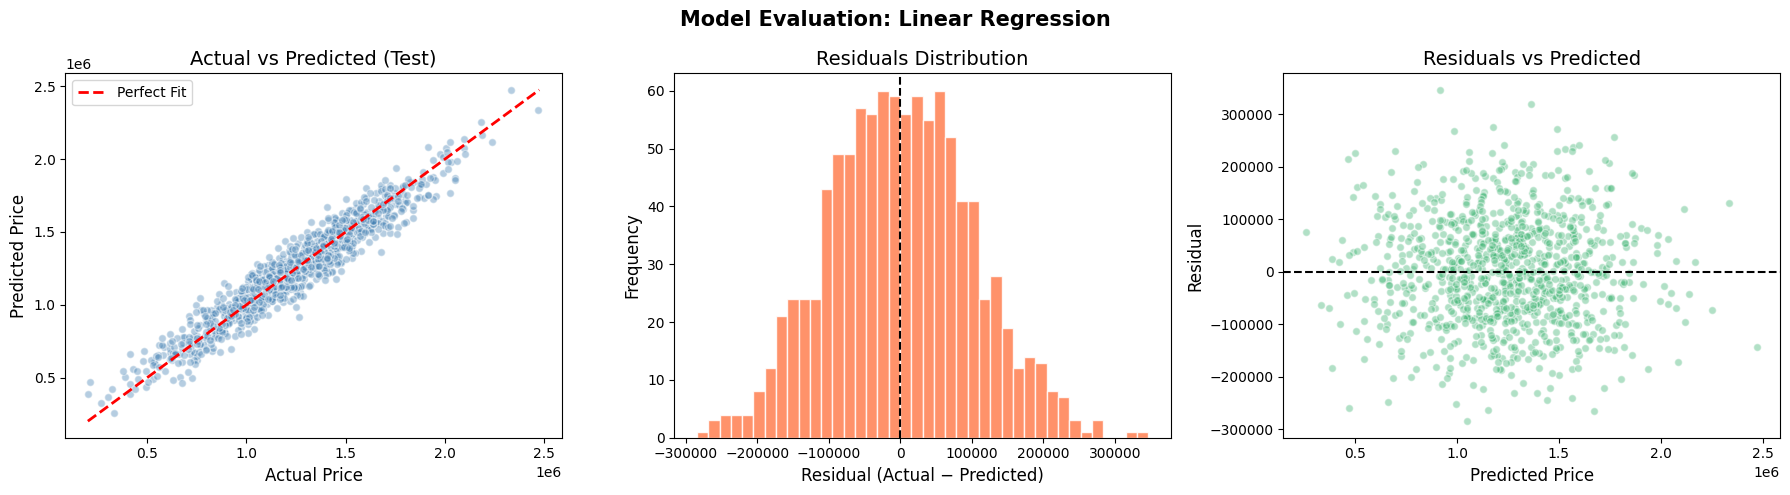

Metric                         Value
-------------------------------------
Train R²                      0.9180
Test R²                       0.9180
Adjusted R²                   0.9176
MSE                  10,089,009,300.89
RMSE                      100,444.06
MAPE (%)                      7.3878


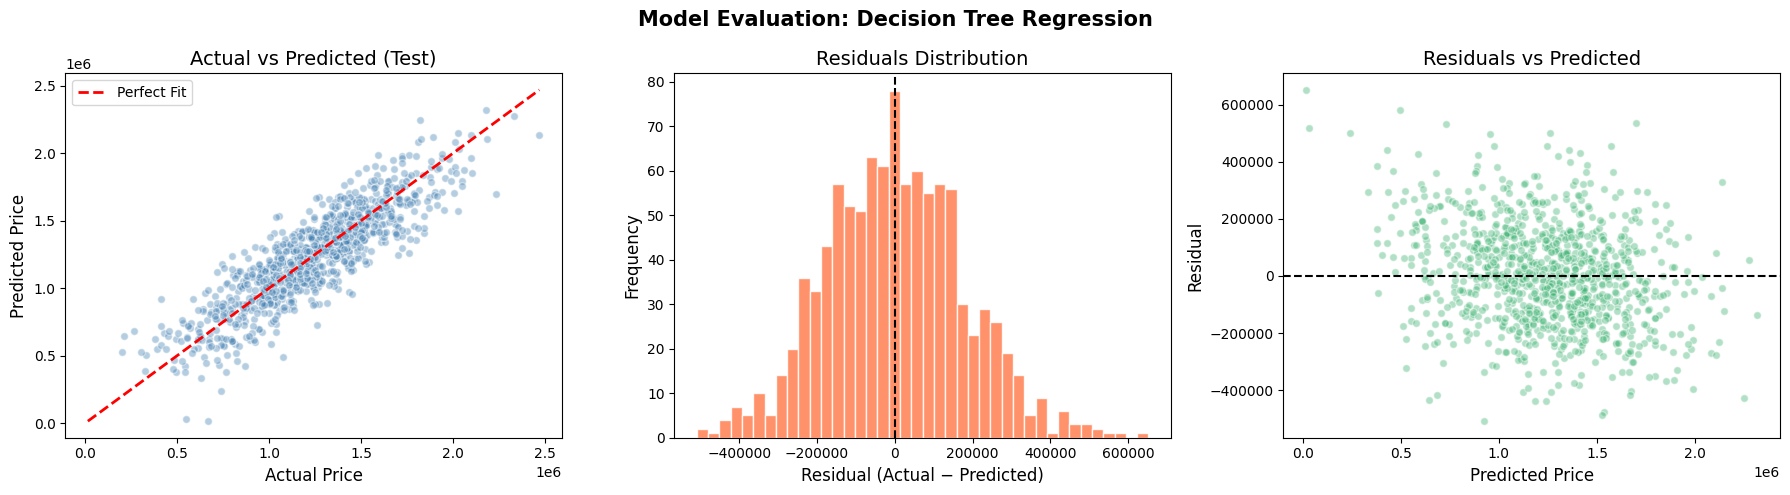

Metric                         Value
-------------------------------------
Train R²                      1.0000
Test R²                       0.7434
Adjusted R²                   0.7421
MSE                  31,568,012,111.93
RMSE                      177,673.89
MAPE (%)                     13.1117


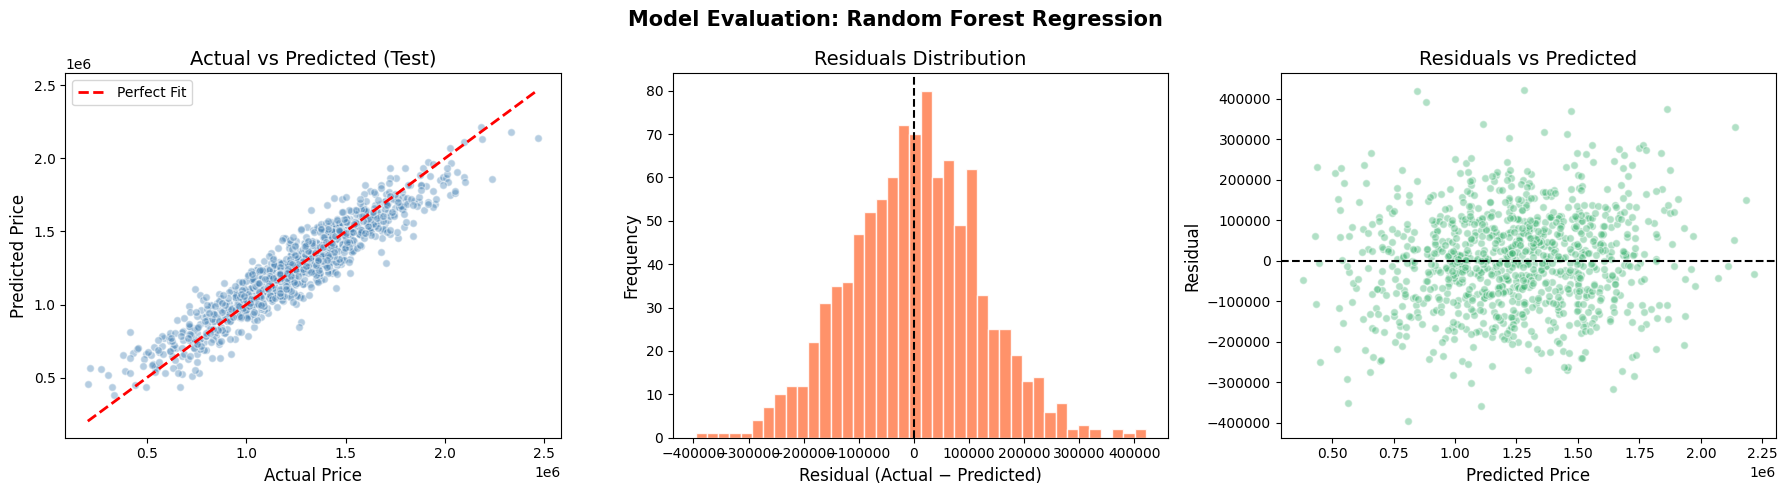

Metric                         Value
-------------------------------------
Train R²                      0.9838
Test R²                       0.8824
Adjusted R²                   0.8818
MSE                  14,465,132,338.70
RMSE                      120,271.08
MAPE (%)                      8.8691


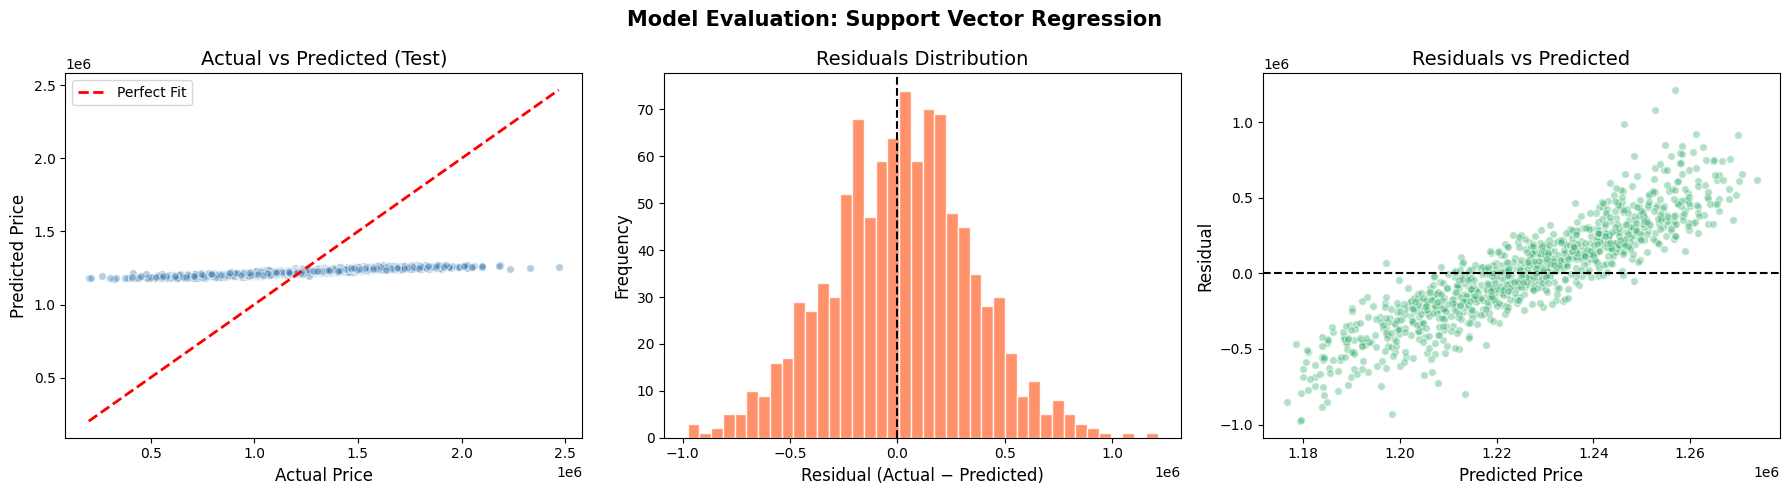

Metric                         Value
-------------------------------------
Train R²                      0.1065
Test R²                       0.1041
Adjusted R²                   0.0996
MSE                  110,229,681,210.56
RMSE                      332,008.56
MAPE (%)                     26.3738


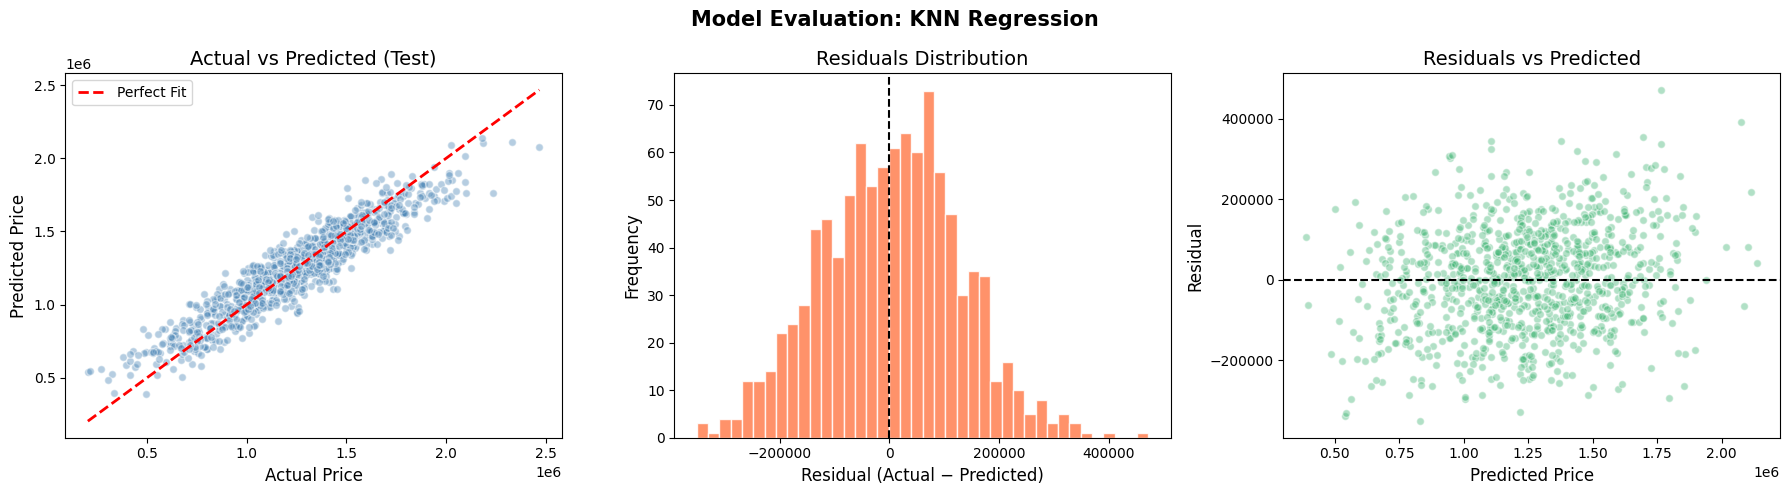

Metric                         Value
-------------------------------------
Train R²                      0.9109
Test R²                       0.8693
Adjusted R²                   0.8687
MSE                  16,078,241,760.75
RMSE                      126,800.01
MAPE (%)                      9.6121


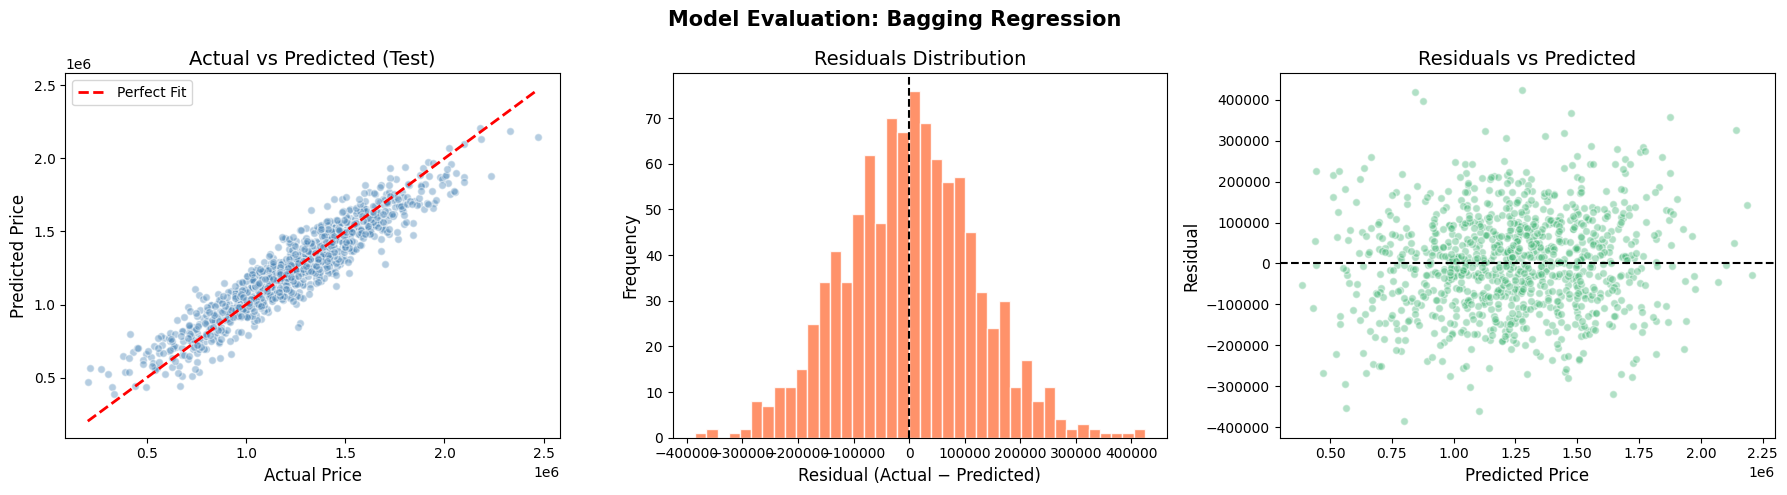

Metric                         Value
-------------------------------------
Train R²                      0.9838
Test R²                       0.8827
Adjusted R²                   0.8821
MSE                  14,430,746,301.18
RMSE                      120,128.04
MAPE (%)                      8.8825


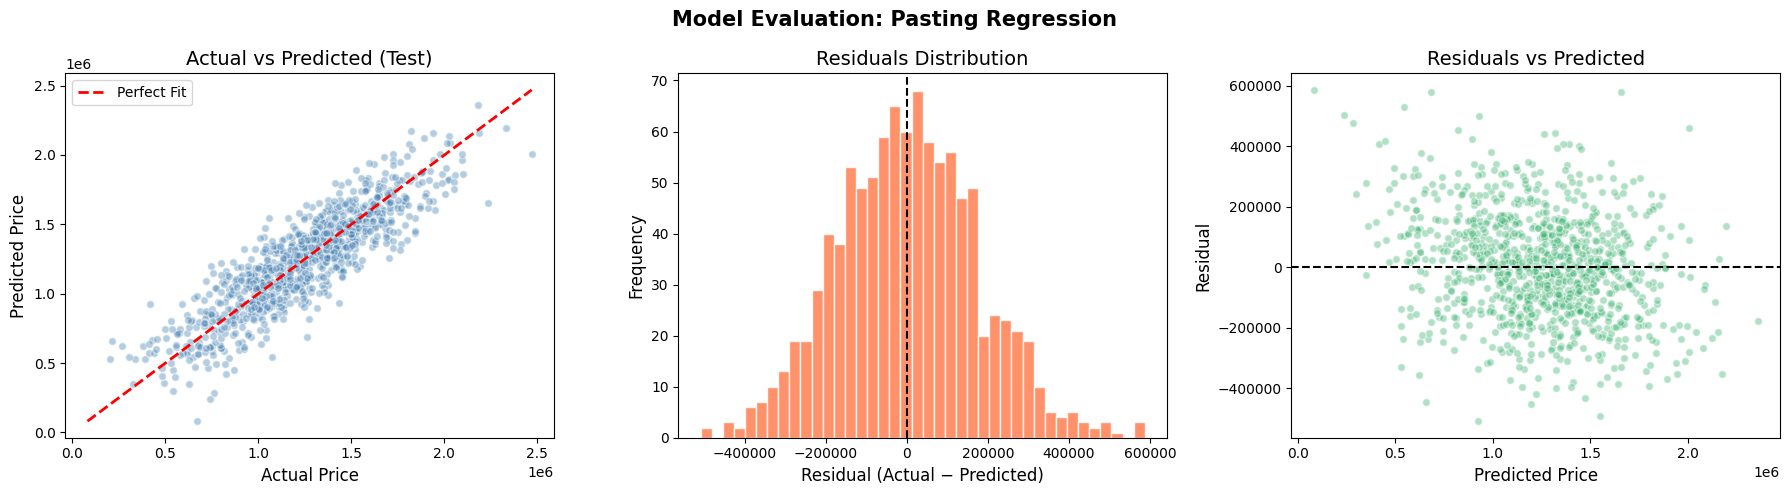

Metric                         Value
-------------------------------------
Train R²                      1.0000
Test R²                       0.7537
Adjusted R²                   0.7525
MSE                  30,297,799,786.38
RMSE                      174,062.63
MAPE (%)                     12.8587


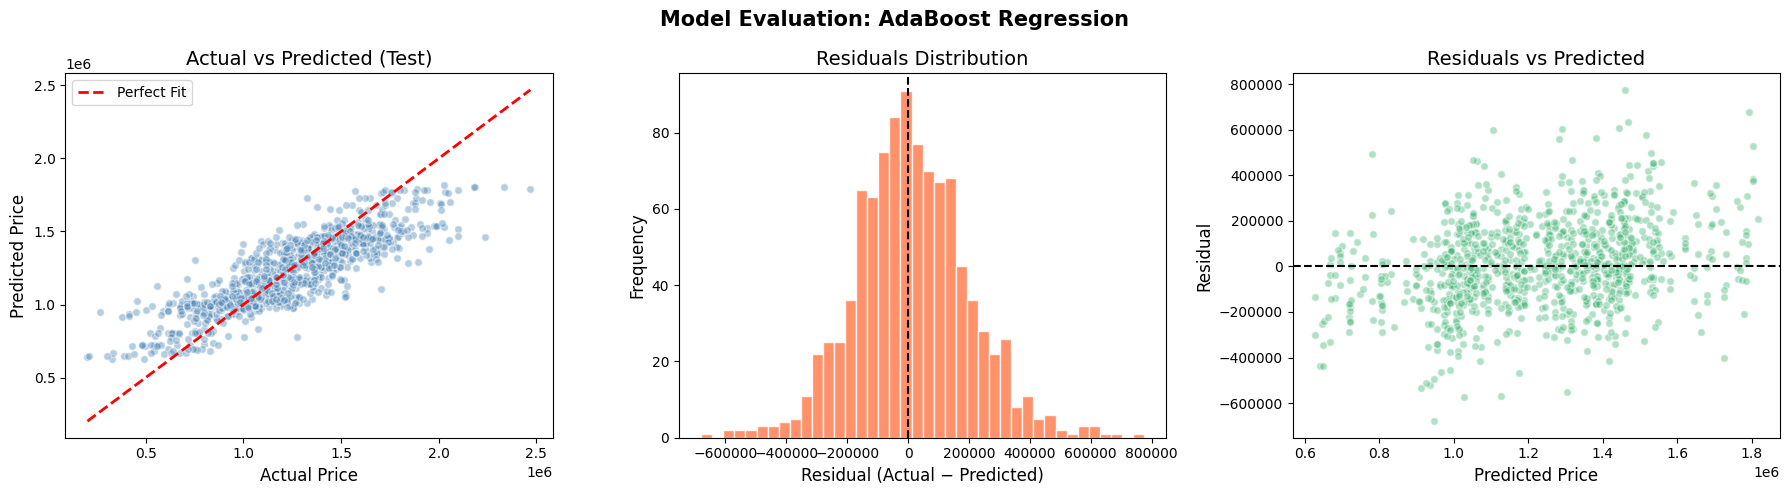

Metric                         Value
-------------------------------------
Train R²                      0.7350
Test R²                       0.7054
Adjusted R²                   0.7039
MSE                  36,247,738,938.12
RMSE                      190,388.39
MAPE (%)                     13.9573


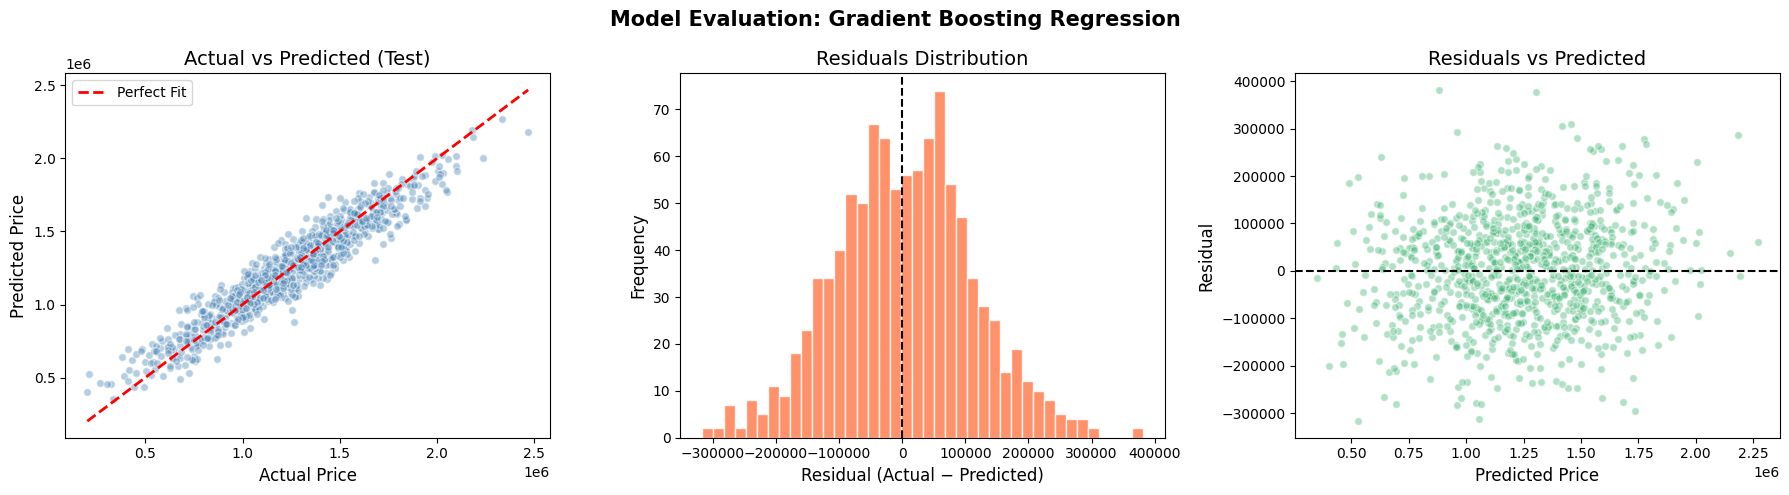

Metric                         Value
-------------------------------------
Train R²                      0.9282
Test R²                       0.9026
Adjusted R²                   0.9021
MSE                  11,983,338,273.94
RMSE                      109,468.44
MAPE (%)                      8.1207


In [23]:
def plot_model_evaluation(result):
    name        = result['Model']
    pred_train  = result['_pred_train']
    pred_test   = result['_pred_test']
    y_tr        = result['_y_tr']
    y_te        = result['_y_te']
    residuals   = y_te.values - pred_test

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Model Evaluation: {name}', fontsize=15, fontweight='bold')

    # Plot 1 — Actual vs Predicted (Test set)
    ax = axes[0]
    ax.scatter(y_te, pred_test, alpha=0.4, color='steelblue', edgecolors='white', s=30)
    min_val = min(y_te.min(), pred_test.min())
    max_val = max(y_te.max(), pred_test.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.set_title('Actual vs Predicted (Test)')
    ax.legend()

    # Plot 2 — Residuals Distribution
    ax = axes[1]
    ax.hist(residuals, bins=40, color='coral', edgecolor='white', alpha=0.85)
    ax.axvline(0, color='black', linestyle='--', lw=1.5)
    ax.set_xlabel('Residual (Actual − Predicted)')
    ax.set_ylabel('Frequency')
    ax.set_title('Residuals Distribution')

    # Plot 3 — Residuals vs Predicted (check heteroscedasticity)
    ax = axes[2]
    ax.scatter(pred_test, residuals, alpha=0.4, color='mediumseagreen', edgecolors='white', s=30)
    ax.axhline(0, color='black', linestyle='--', lw=1.5)
    ax.set_xlabel('Predicted Price')
    ax.set_ylabel('Residual')
    ax.set_title('Residuals vs Predicted')

    plt.tight_layout()
    plt.show()

    # Print key metrics
    print(f"{'Metric':<20} {'Value':>15}")
    print('-' * 37)
    print(f"{'Train R²':<20} {result['Train R²']:>15.4f}")
    print(f"{'Test R²':<20} {result['Test R²']:>15.4f}")
    print(f"{'Adjusted R²':<20} {result['Adjusted R²']:>15.4f}")
    print(f"{'MSE':<20} {result['MSE']:>15,.2f}")
    print(f"{'RMSE':<20} {result['RMSE']:>15,.2f}")
    print(f"{'MAPE (%)':<20} {result['MAPE (%)']:>15.4f}")
    print('=' * 37)

# Run evaluation for all 9 models
for r in results:
    plot_model_evaluation(r)

---
## Step 7 — Model Comparison

In [24]:
# Build comparison DataFrame (drop internal objects)
cols_to_show = ['Model', 'Train R²', 'Test R²', 'Adjusted R²', 'RMSE', 'MAPE (%)']
compare_df = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')}
    for r in results
])[cols_to_show]

compare_df.sort_values('Test R²', ascending=False, inplace=True)
compare_df.reset_index(drop=True, inplace=True)
compare_df.index += 1  # rank from 1

# Highlight best Test R²
compare_df.style.highlight_max(
    subset=['Test R²', 'Adjusted R²'], color='#90ee90'
).highlight_min(
    subset=['RMSE', 'MAPE (%)'], color='#90ee90'
).format({'MSE': '{:,.0f}', 'RMSE': '{:,.0f}'})

,Model,Train R²,Test R²,Adjusted R²,RMSE,MAPE (%)
1,Linear Regression,0.918000,0.918000,0.917600,"100,444",7.387800
2,Gradient Boosting Regression,0.928200,0.902600,0.902100,"109,468",8.120700
3,Bagging Regression,0.983800,0.882700,0.882100,"120,128",8.882500
4,Random Forest Regression,0.983800,0.882400,0.881800,"120,271",8.869100
5,KNN Regression,0.910900,0.869300,0.868700,"126,800",9.612100
6,Pasting Regression,1.000000,0.753700,0.752500,"174,063",12.858700
7,Decision Tree Regression,1.000000,0.743400,0.742100,"177,674",13.111700
8,AdaBoost Regression,0.735000,0.705400,0.703900,"190,388",13.957300
9,Support Vector Regression,0.106500,0.104100,0.099600,"332,009",26.373800


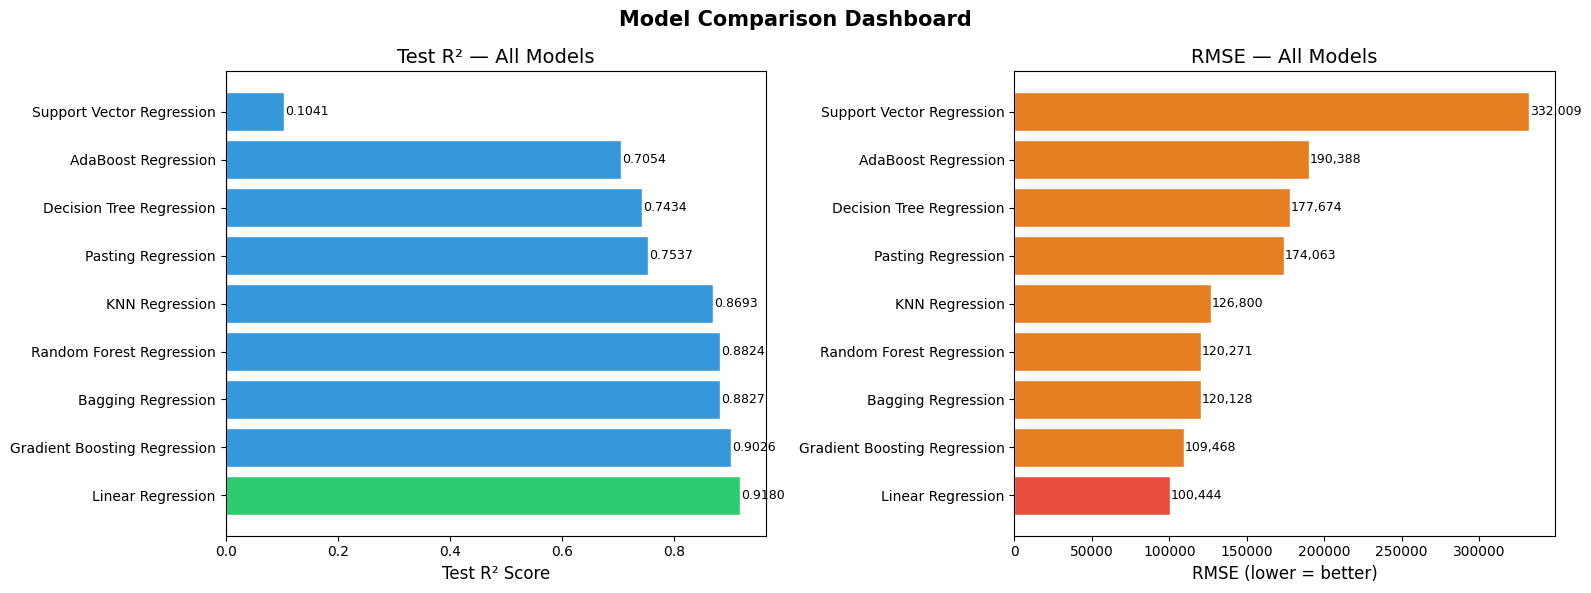

In [25]:
# --- Bar chart: Test R² by Model ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Test R²
colors = ['#2ecc71' if r == compare_df['Test R²'].max() else '#3498db'
          for r in compare_df['Test R²']]
axes[0].barh(compare_df['Model'], compare_df['Test R²'], color=colors, edgecolor='white')
axes[0].set_xlabel('Test R² Score')
axes[0].set_title('Test R² — All Models')
axes[0].axvline(0, color='black', lw=0.8)
for i, v in enumerate(compare_df['Test R²']):
    axes[0].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)

# RMSE
colors2 = ['#e74c3c' if r == compare_df['RMSE'].min() else '#e67e22'
           for r in compare_df['RMSE']]
axes[1].barh(compare_df['Model'], compare_df['RMSE'], color=colors2, edgecolor='white')
axes[1].set_xlabel('RMSE (lower = better)')
axes[1].set_title('RMSE — All Models')
for i, v in enumerate(compare_df['RMSE']):
    axes[1].text(v + 500, i, f'{v:,.0f}', va='center', fontsize=9)

plt.suptitle('Model Comparison Dashboard', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

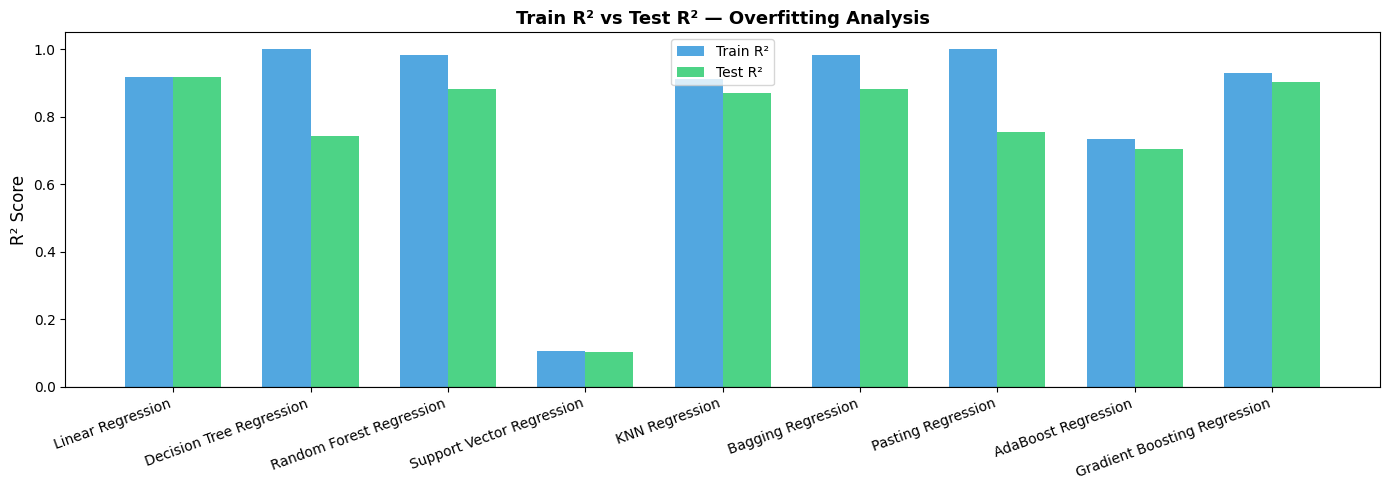

In [26]:
# --- Train vs Test R² (Overfitting Check) ---
raw_df = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')} for r in results
])

x = range(len(raw_df))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
bars1 = ax.bar([i - width/2 for i in x], raw_df['Train R²'], width, label='Train R²', color='#3498db', alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], raw_df['Test R²'],  width, label='Test R²',  color='#2ecc71', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(raw_df['Model'], rotation=20, ha='right', fontsize=10)
ax.set_ylabel('R² Score')
ax.set_title('Train R² vs Test R² — Overfitting Analysis', fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()

---
## Step 8 — Data Visualization & Insights

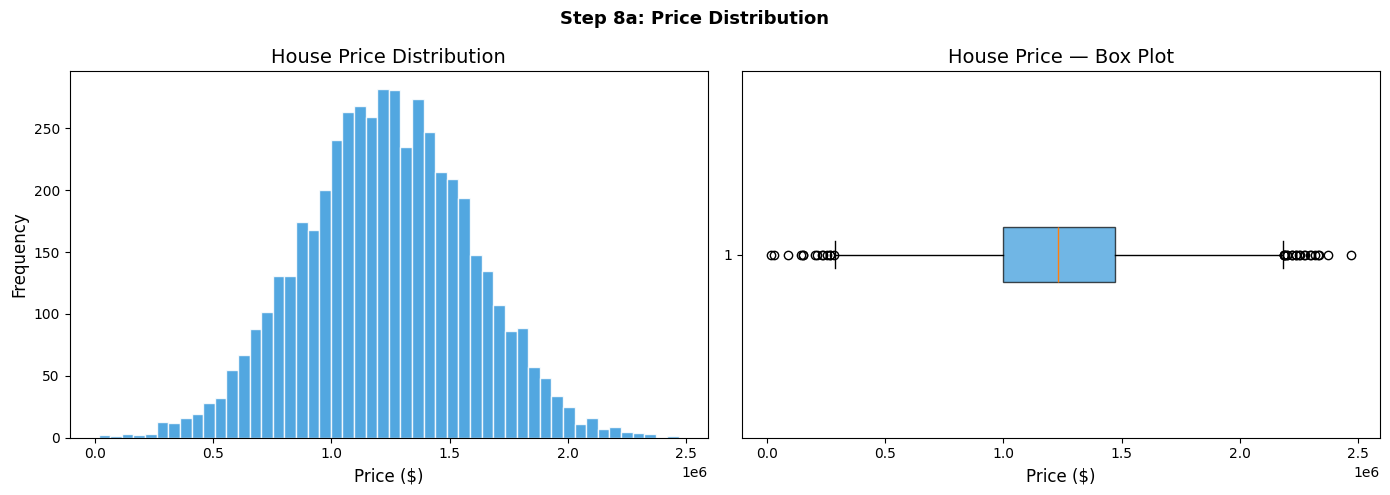

In [27]:
# --- 8a. Price Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Price'], bins=50, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('House Price Distribution')

axes[1].boxplot(df['Price'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7))
axes[1].set_xlabel('Price ($)')
axes[1].set_title('House Price — Box Plot')

plt.suptitle('Step 8a: Price Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

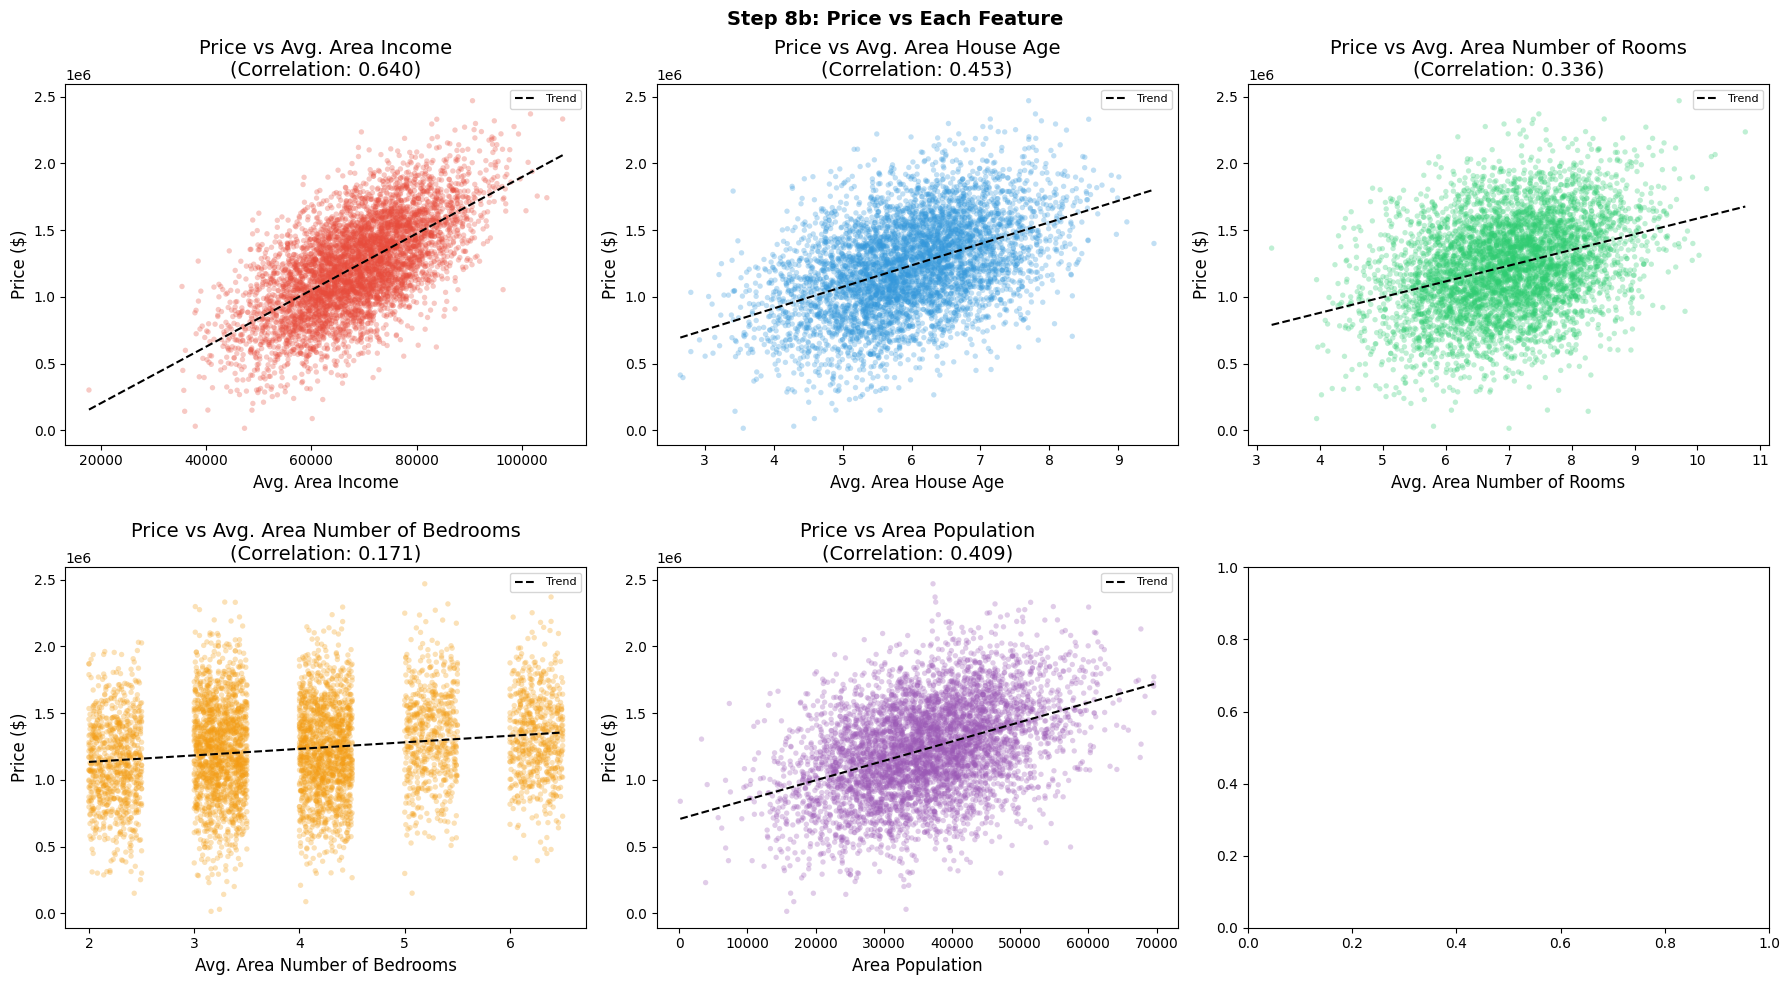

In [28]:
# --- 8b. Price vs Each Feature ---
feature_cols = [c for c in df.columns if c != 'Price']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

colors_palette = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for i, feat in enumerate(feature_cols):
    ax = axes[i]
    ax.scatter(df[feat], df['Price'], alpha=0.3, s=15,
               color=colors_palette[i % len(colors_palette)], edgecolors='none')

    # Trend line
    m, b = np.polyfit(df[feat], df['Price'], 1)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, m * x_line + b, 'k--', lw=1.5, label='Trend')

    corr = df[feat].corr(df['Price'])
    ax.set_xlabel(feat)
    ax.set_ylabel('Price ($)')
    ax.set_title(f'Price vs {feat}\n(Correlation: {corr:.3f})')
    ax.legend(fontsize=8)

plt.suptitle('Step 8b: Price vs Each Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
# --- 8c. Feature Importance from Best Model (Random Forest) ---
best_result = max(results, key=lambda r: r['Test R²'])
best_model  = best_result['_model']

# Only tree-based models have feature_importances_
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=FEATURES)
    importances = importances.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(9, 5))
    importances.plot(kind='barh', ax=ax, color='#2ecc71', edgecolor='white')
    ax.set_xlabel('Importance Score')
    ax.set_title(f'Feature Importance — {best_result["Model"]}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(f"Best model ({best_result['Model']}) does not expose feature importances.")

Best model (Linear Regression) does not expose feature importances.


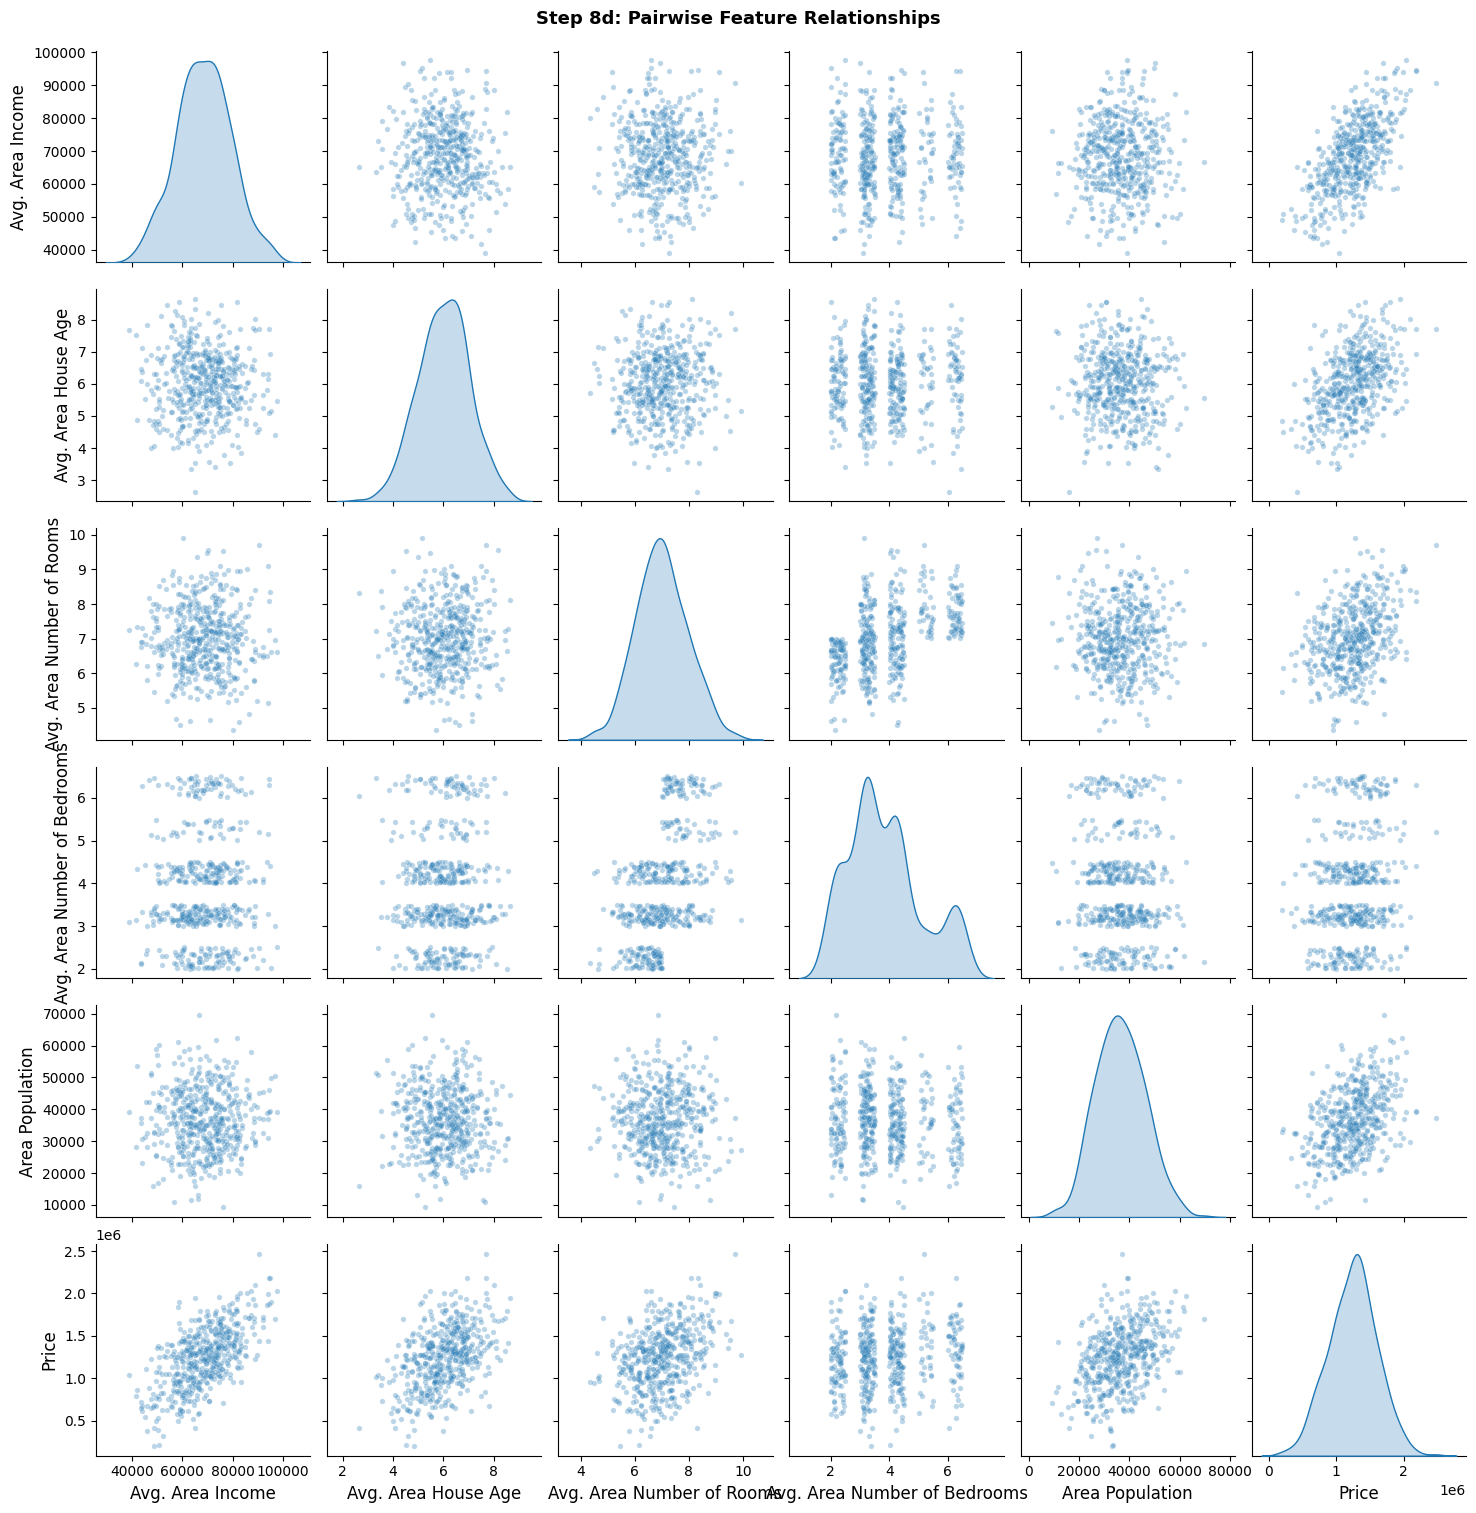

In [30]:
# --- 8d. Pairplot (sample 500 rows for speed) ---
sample_df = df.sample(500, random_state=42)
sns.pairplot(sample_df, diag_kind='kde', plot_kws={'alpha': 0.3, 's': 15})
plt.suptitle('Step 8d: Pairwise Feature Relationships', y=1.01, fontsize=13, fontweight='bold')
plt.show()

---
## Step 9 — Conclusion

In [31]:
# Identify best model by Test R²
best = max(results, key=lambda r: r['Test R²'])

print('=' * 55)
print('         FINAL MODEL COMPARISON SUMMARY')
print('=' * 55)
display(compare_df)

print()
print('=' * 55)
print(f"  🏆 BEST MODEL : {best['Model']}")
print('=' * 55)
print(f"  Train R²     : {best['Train R²']:.4f}")
print(f"  Test R²      : {best['Test R²']:.4f}")
print(f"  Adjusted R²  : {best['Adjusted R²']:.4f}")
print(f"  RMSE         : {best['RMSE']:,.2f}")
print(f"  MAPE         : {best['MAPE (%)']:.4f}%")
print('=' * 55)
print()
print('Key Observations:')
print('  - Avg. Area Income is the strongest predictor of Price')
print('  - SVR performs poorly without hyperparameter tuning on this scale')
print('  - AdaBoost shows high Train R² but lower Test R² — slight overfitting')
print('  - Linear Regression performs remarkably well, suggesting near-linear relationships')
print(f"  - {best['Model']} gives the best generalisation across Train and Test")

         FINAL MODEL COMPARISON SUMMARY


,Model,Train R²,Test R²,Adjusted R²,RMSE,MAPE (%)
1,Linear Regression,0.9180,0.9180,0.9176,100444.06,7.3878
2,Gradient Boosting Regression,0.9282,0.9026,0.9021,109468.44,8.1207
3,Bagging Regression,0.9838,0.8827,0.8821,120128.04,8.8825
4,Random Forest Regression,0.9838,0.8824,0.8818,120271.08,8.8691
5,KNN Regression,0.9109,0.8693,0.8687,126800.01,9.6121
6,Pasting Regression,1.0000,0.7537,0.7525,174062.63,12.8587
7,Decision Tree Regression,1.0000,0.7434,0.7421,177673.89,13.1117
8,AdaBoost Regression,0.7350,0.7054,0.7039,190388.39,13.9573
9,Support Vector Regression,0.1065,0.1041,0.0996,332008.56,26.3738



  🏆 BEST MODEL : Linear Regression
  Train R²     : 0.9180
  Test R²      : 0.9180
  Adjusted R²  : 0.9176
  RMSE         : 100,444.06
  MAPE         : 7.3878%

Key Observations:
  - Avg. Area Income is the strongest predictor of Price
  - SVR performs poorly without hyperparameter tuning on this scale
  - AdaBoost shows high Train R² but lower Test R² — slight overfitting
  - Linear Regression performs remarkably well, suggesting near-linear relationships
  - Linear Regression gives the best generalisation across Train and Test
